EJERCICIO 1

Recorta el punto de interés de la imagenP.jpg tal cual se muestra en la figura, guarda 
la imagen recortada en tu disco local, y muestra la imagen original y la recortada con 
axis (imagen a colores) 

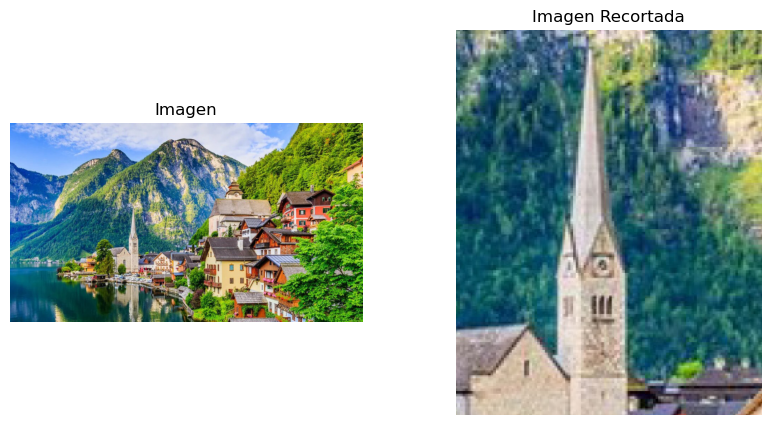

In [36]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('imagenP.jpeg')
img_recortada = img[450:740, 570:800]  
#cv2.imwrite('lena_recortada.png', img_recortada)  


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen')
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))  
plt.title('Imagen Recortada')
plt.axis('off')
plt.show()

EJERCICIO 2

Genera un degradado lineal a colores (debe coincidir con los mismos colores). 

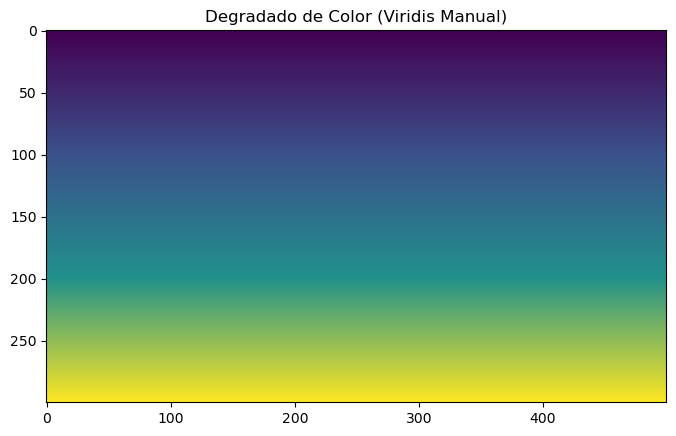

In [52]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt


degradado = np.zeros((300, 500, 3), dtype=np.uint8)
for i in range(300):
    color = plt.cm.viridis(i / 300)
    degradado[i, :] = (np.array(color[:3]) * 255).astype(np.uint8)

plt.imshow(degradado)
plt.title('Degradado de Color')
plt.show()

EJERCICIO 3

Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada 
casilla debe medir 100x100 px 

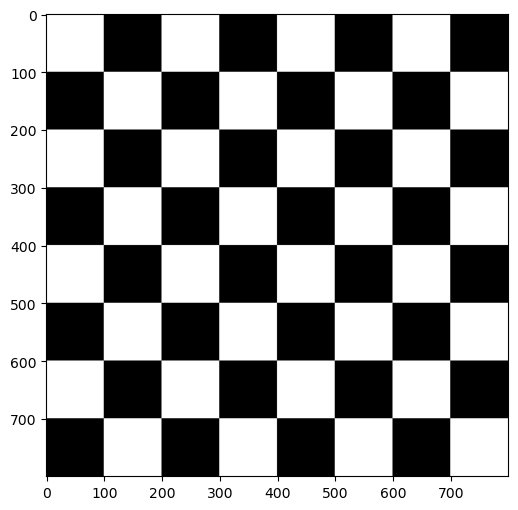

In [104]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=[6,6]

tam = 100

imagen = np.ones((tam*8, tam*8, 3), dtype=np.uint8) * 255

negro = [0, 0, 0]

imagen[0:100, 100:200] = negro
imagen[0:100, 300:400] = negro
imagen[0:100, 500:600] = negro
imagen[0:100, 700:800] = negro

imagen[100:200, 0:100] = negro
imagen[100:200, 200:300] = negro
imagen[100:200, 400:500] = negro
imagen[100:200, 600:700] = negro


imagen[200:300, 100:200] = negro
imagen[200:300, 300:400] = negro
imagen[200:300, 500:600] = negro
imagen[200:300, 700:800] = negro


imagen[300:400, 0:100] = negro
imagen[300:400, 200:300] = negro
imagen[300:400, 400:500] = negro
imagen[300:400, 600:700] = negro

imagen[400:500, 100:200] = negro
imagen[400:500, 300:400] = negro
imagen[400:500, 500:600] = negro
imagen[400:500, 700:800] = negro

imagen[500:600, 0:100] = negro
imagen[500:600, 200:300] = negro
imagen[500:600, 400:500] = negro
imagen[500:600, 600:700] = negro

imagen[600:700, 100:200] = negro
imagen[600:700, 300:400] = negro
imagen[600:700, 500:600] = negro
imagen[600:700, 700:800] = negro

imagen[700:800, 0:100] = negro
imagen[700:800, 200:300] = negro
imagen[700:800, 400:500] = negro
imagen[700:800, 600:700] = negro


plt.imshow(imagen)
plt.show()

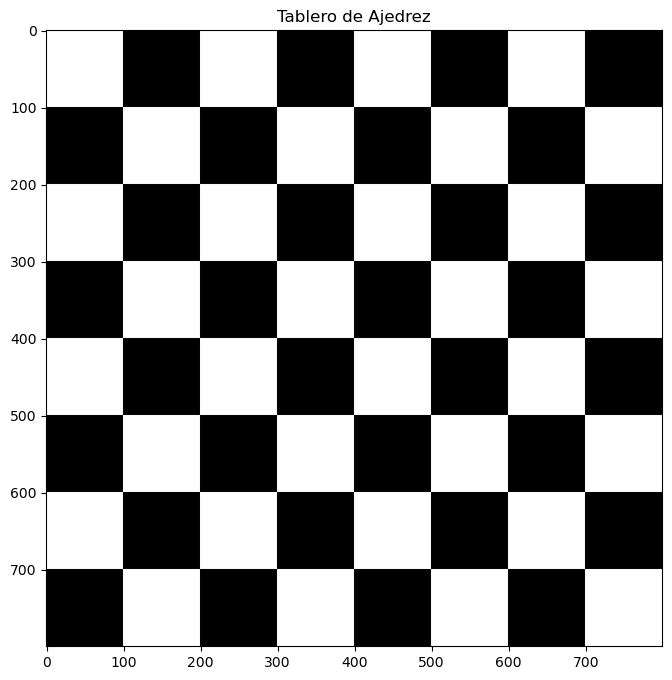

In [74]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (8, 8)
size = 800
third = size // 8
imagen = np.zeros((size, size, 3), dtype=np.uint8)

for i in range(size):
    for j in range(size):
        if (i // third + j // third) % 2 == 0:
            imagen[i, j] = [255, 255, 255]
        else:
            imagen[i, j] = [0, 0, 0]

plt.figure()
plt.imshow(imagen)
plt.title('Tablero de Ajedrez')
plt.show()

EJERCICIO 4

Tomando en cuenta el resultado del ejercicio 2 aplica posterizacion y solarizacion, de 
la misma manera aplica todas las paletas de falso color cada resultado debe 
guardarse. 

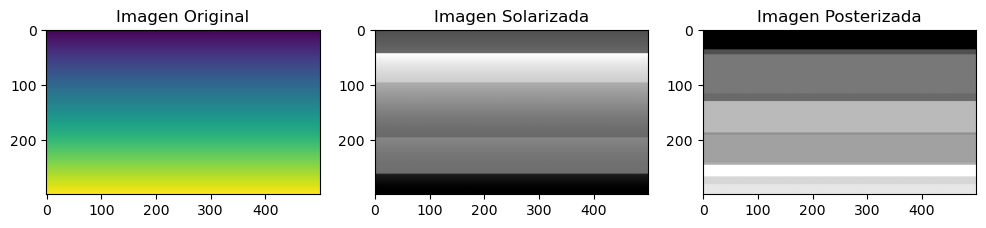

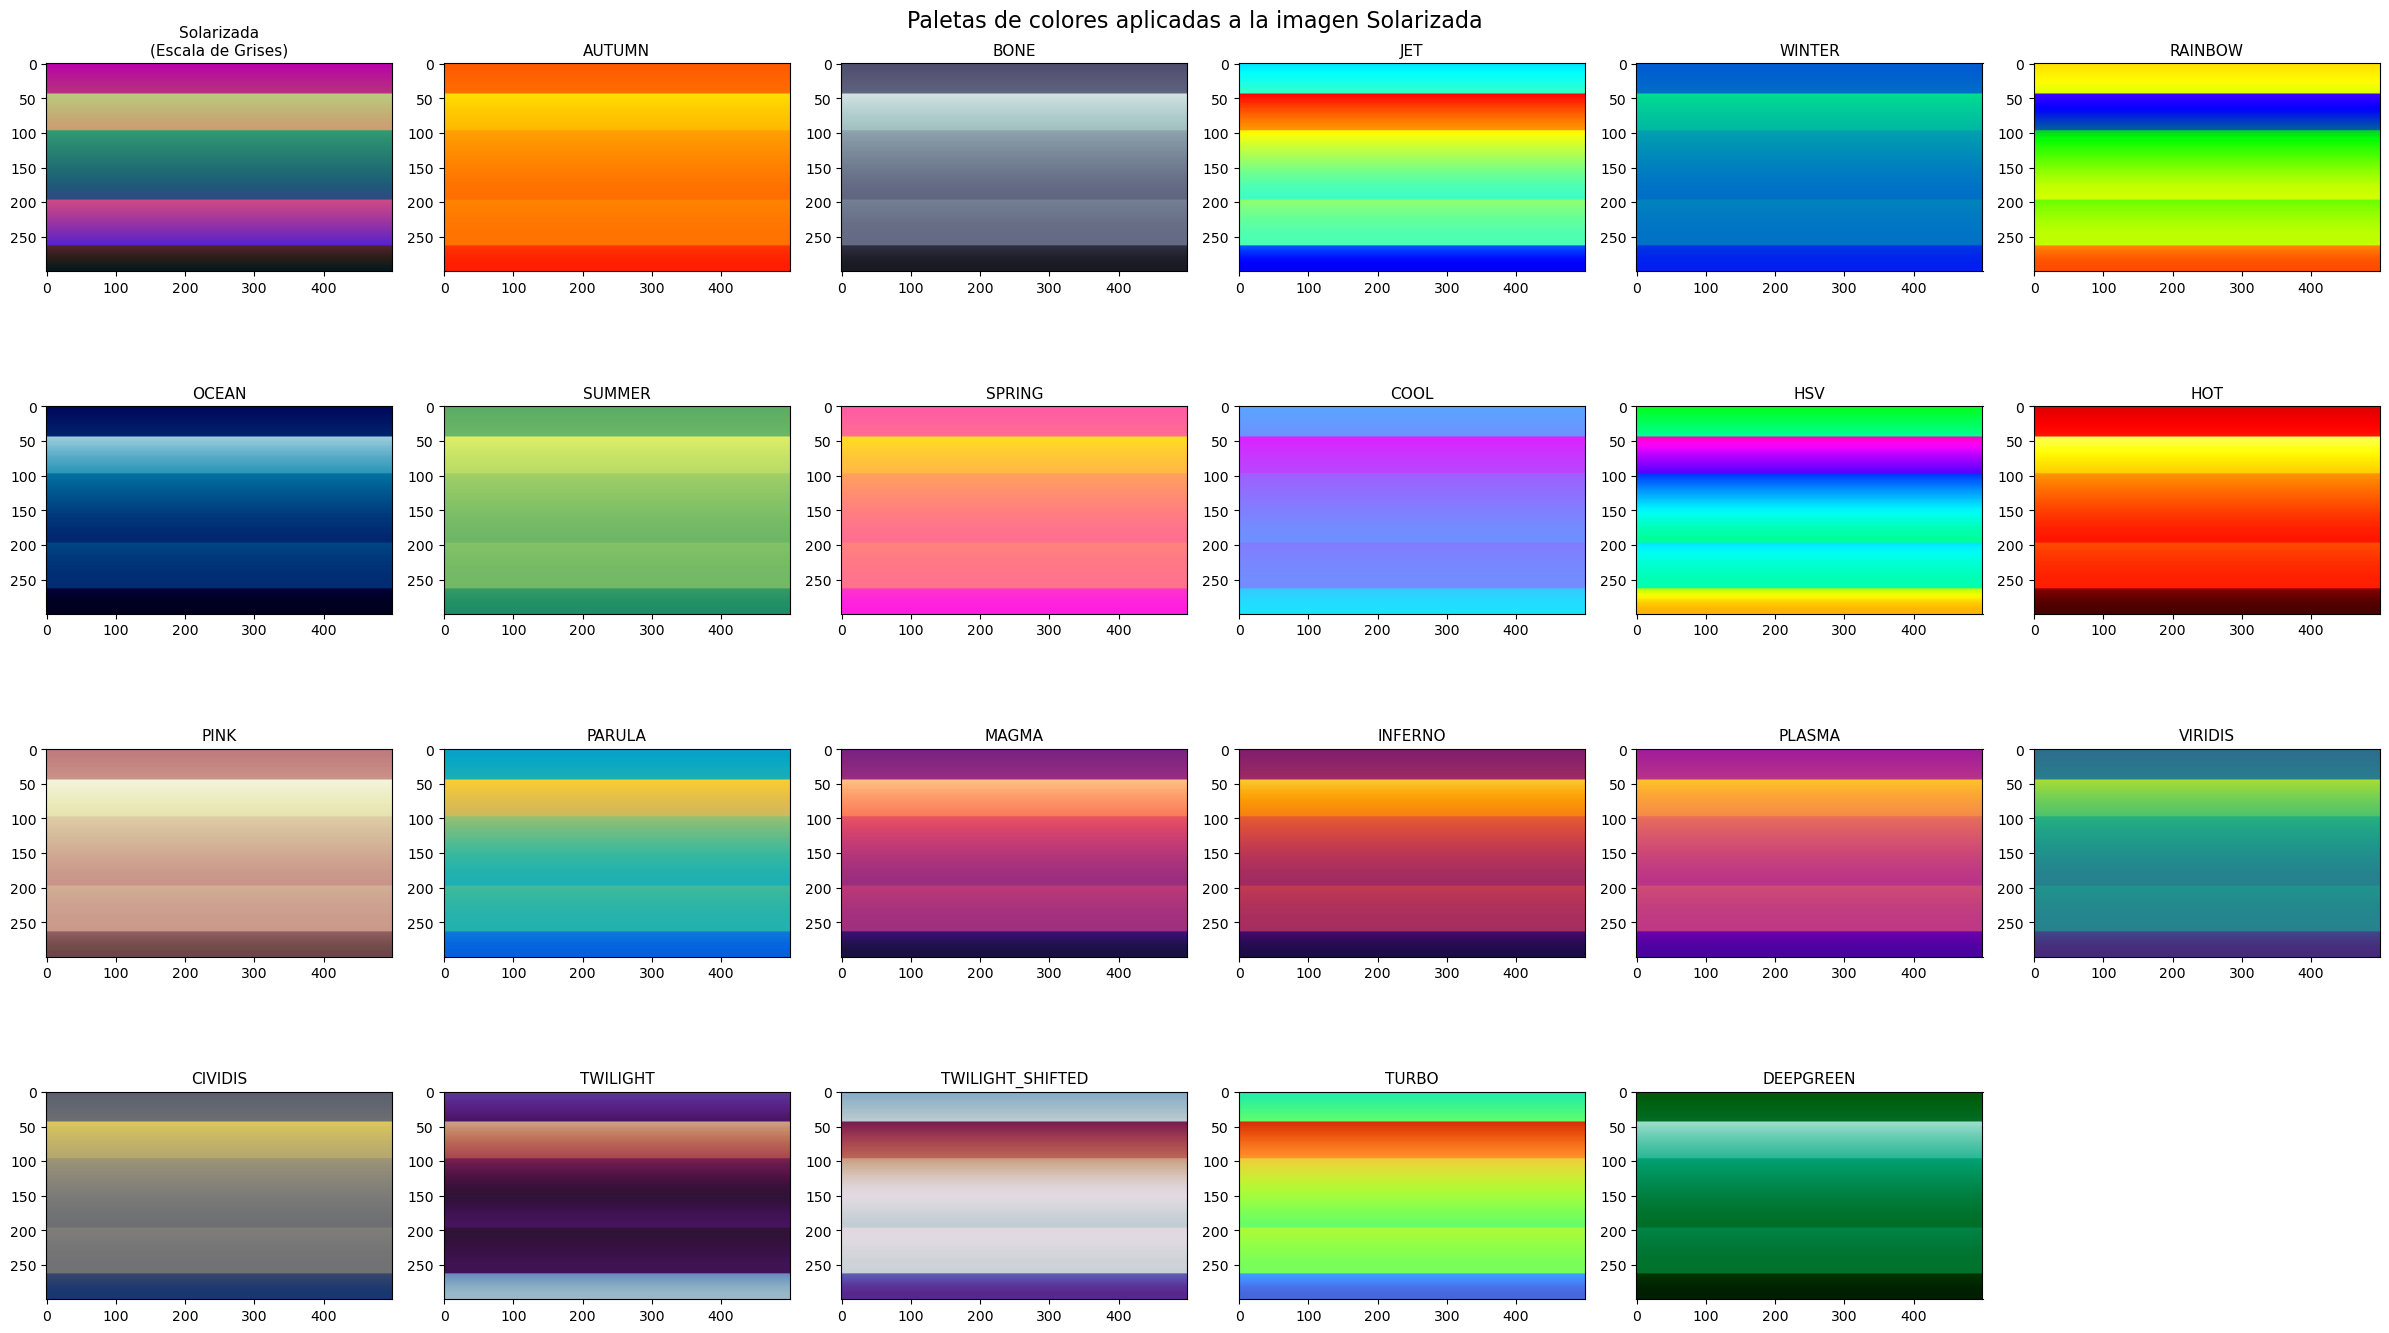

In [108]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = degradado

def posterizar(imagen, niveles):
    # APLICAMOS POSTERIZACION A LA IMAGEN
    factor_escala = 256 // niveles
    imagen_post = np.round(imagen / factor_escala) * factor_escala
    return imagen_post.astype(np.uint8) # Convertir a uint8 para mantener el formato de imagen

def solarizar(imagen, umbral):
    # APLICAMOS SOLARIZACION A LA IMAGEN
    imagen_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return imagen_sol

umbral = 50  # Definir el umbral para la solarización
img_fin_sol = solarizar(imagen, umbral)  # Aplicar la función de solarización

nvles = 3  # Definir el número de niveles para la posterización
img_fin_pos = posterizar(imagen, nvles)  # Aplicar la función de posterización

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(degradado)  # USANDO VARIABLE DEGRADADO

plt.subplot(1, 3, 2)
plt.title('Imagen Solarizada')
plt.imshow(cv2.cvtColor(img_fin_sol, cv2.COLOR_BGR2GRAY), cmap='gray')  # Mostrar la imagen solarizada

plt.subplot(1, 3, 3)
plt.title('Imagen Posterizada')
plt.imshow(cv2.cvtColor(img_fin_pos, cv2.COLOR_BGR2GRAY), cmap='gray')  # Mostrar la imagen posterizada
plt.show()

def falso_color(img_gray, colormap=None):
    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    if colormap is None:
        return img_gray 
    else:
        return cv2.applyColorMap(escal_img, colormap)

img_gray = cv2.cvtColor(degradado, cv2.COLOR_BGR2GRAY)


colormap_list = [
    ("Original (Grises)", None),
    ("AUTUMN", cv2.COLORMAP_AUTUMN),
    ("BONE", cv2.COLORMAP_BONE),
    ("JET", cv2.COLORMAP_JET),
    ("WINTER", cv2.COLORMAP_WINTER),
    ("RAINBOW", cv2.COLORMAP_RAINBOW),
    ("OCEAN", cv2.COLORMAP_OCEAN),
    ("SUMMER", cv2.COLORMAP_SUMMER),
    ("SPRING", cv2.COLORMAP_SPRING),
    ("COOL", cv2.COLORMAP_COOL),
    ("HSV", cv2.COLORMAP_HSV),
    ("HOT", cv2.COLORMAP_HOT),
    ("PINK", cv2.COLORMAP_PINK),
    ("PARULA", cv2.COLORMAP_PARULA),
    ("MAGMA", cv2.COLORMAP_MAGMA),
    ("INFERNO", cv2.COLORMAP_INFERNO),
    ("PLASMA", cv2.COLORMAP_PLASMA),
    ("VIRIDIS", cv2.COLORMAP_VIRIDIS),
    ("CIVIDIS", cv2.COLORMAP_CIVIDIS),
    ("TWILIGHT", cv2.COLORMAP_TWILIGHT),
    ("TWILIGHT_SHIFTED", cv2.COLORMAP_TWILIGHT_SHIFTED),
    ("TURBO", cv2.COLORMAP_TURBO),
    ("DEEPGREEN", cv2.COLORMAP_DEEPGREEN),
]

plt.figure(figsize=(24, 14))

for i, (nombre, colormap) in enumerate(colormap_list):
    plt.subplot(4, 6, i + 1)
   
    if nombre == "Original (Grises)":
        plt.title('Solarizada\n(Escala de Grises)', fontsize=11)
        plt.imshow(img_fin_sol, cmap='gray')
    else:
        img_fin = falso_color(img_fin_sol, colormap)
        plt.title(nombre, fontsize=11)
        plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
   
plt.tight_layout()
plt.suptitle("Paletas de colores aplicadas a la imagen Solarizada", fontsize=16, y=0.98)
plt.show()

EJERCICIO 5.

Tomando en cuenta la imagen1.jpg aplica un degradado lineal en ella.

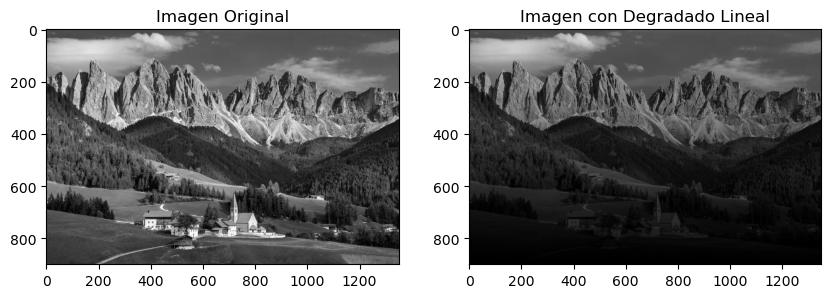

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen1.jpeg',0)

degradado = np. linspace(1, 0, imagen. shape[0] ) [:, np.newaxis]
mascara = np.tile(degradado, (1, imagen.shape[1]))
imagen_degradada = (imagen.astype(np.float32) * mascara).astype(np.uint8)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(imagen_degradada, cv2.COLOR_BGR2RGB))
plt.title('Imagen con Degradado Lineal')
plt.show()

EJERCICIO 6

Elabora una imagen original, usando unicamente cuadrados, no tiene que parecerse
a los ejecicios realizados en clase , posterior debe aplicarse el filtro bayer en todas
sus convinaciones mostrar y guardar todos los resultados con sus titulos
correspondientes.

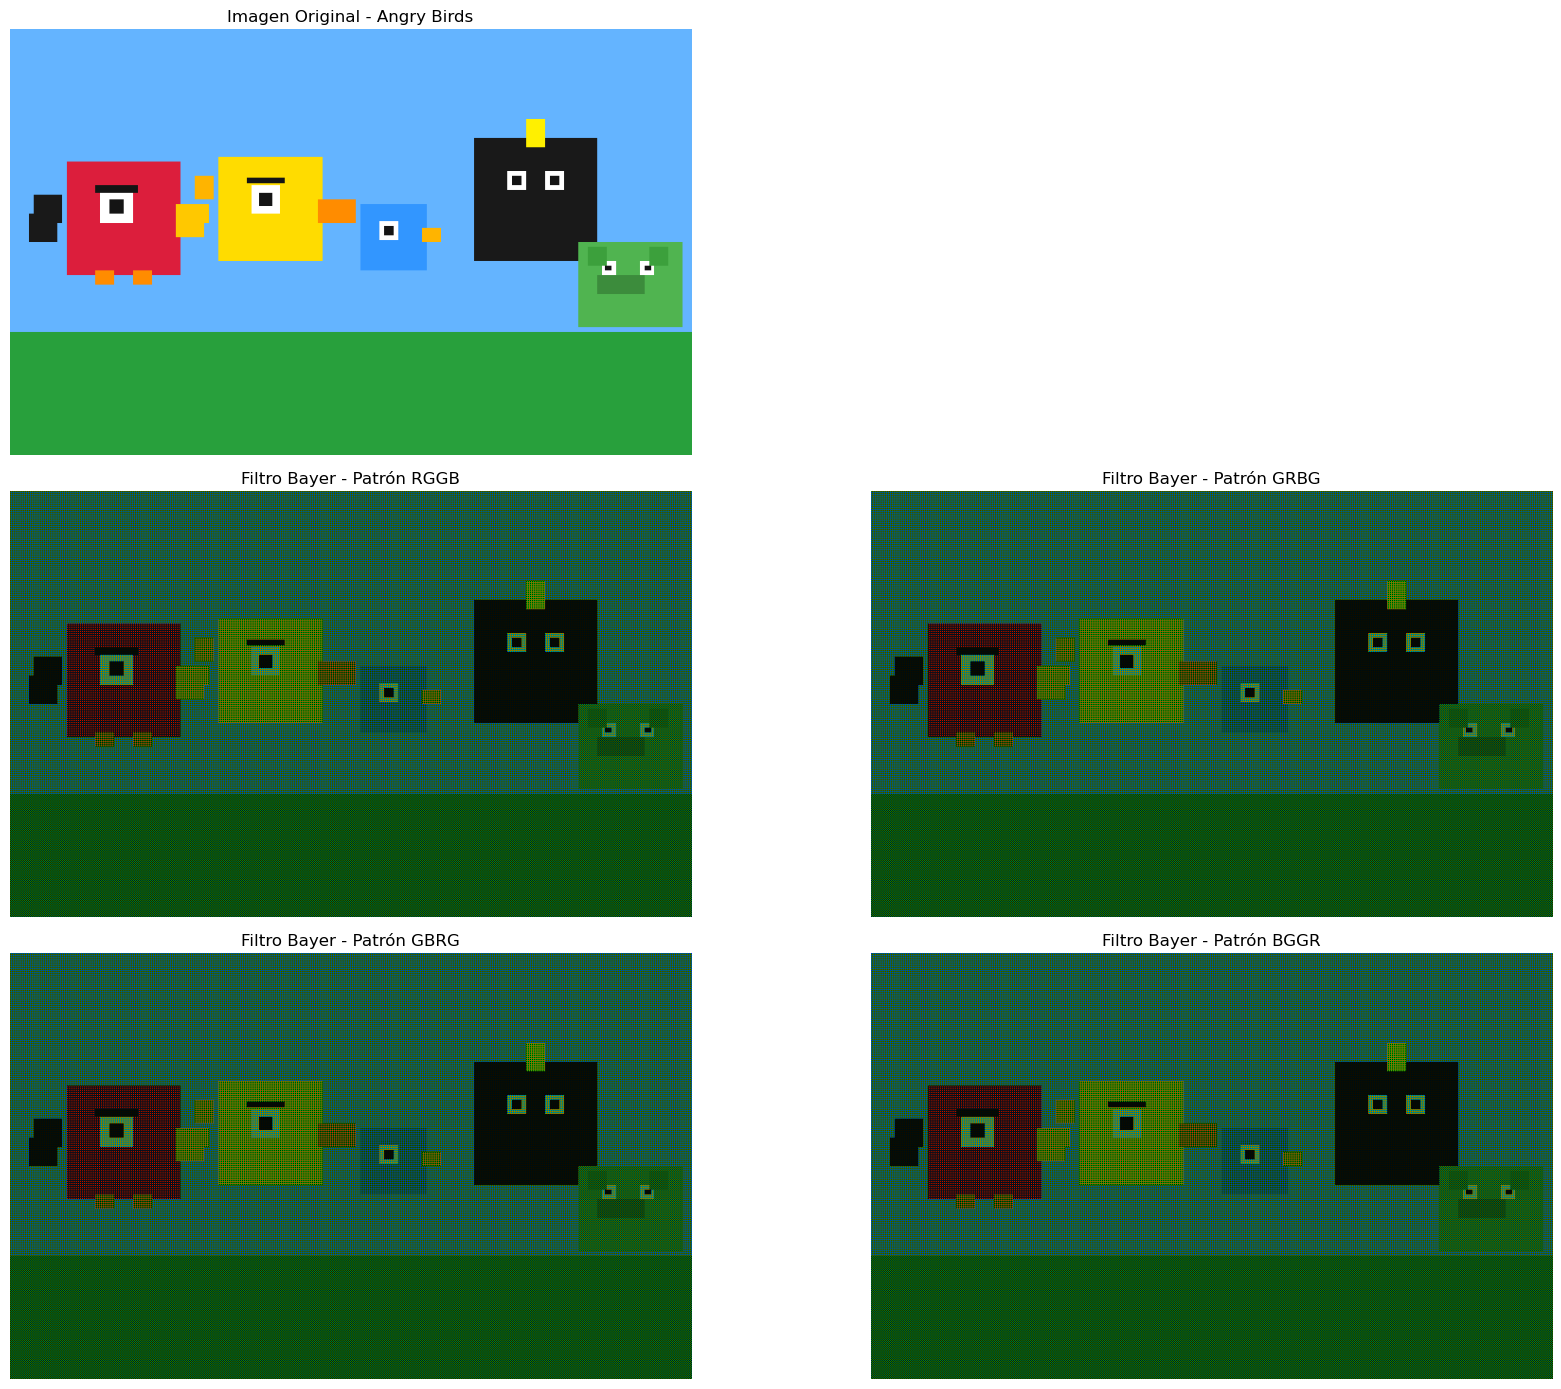

Imágenes guardadas correctamente:
- angry_birds_original.png
- angry_birds_bayer_RGGB.png
- angry_birds_bayer_GRBG.png
- angry_birds_bayer_GBRG.png
- angry_birds_bayer_BGGR.png


In [38]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 450, 720
img = np.zeros((height, width, 3), dtype=np.uint8)

img[:, :] = [100, 180, 255]
img[320:, :] = [40, 160, 60]

def dibujar_pajaro_rojo(x, y):
    img[y:y+120, x:x+120] = [220, 30, 60]
    img[y+35:y+65, x-35:x-5] = [25, 25, 25]
    img[y+55:y+85, x-40:x-10] = [25, 25, 25]
    img[y+45:y+65, x+115:x+150] = [255, 200, 0]
    img[y+60:y+80, x+115:x+145] = [255, 200, 0]
    img[y+30:y+65, x+35:x+70] = [255, 255, 255]
    img[y+40:y+55, x+45:x+60] = [20, 20, 20]
    img[y+25:y+33, x+30:x+75] = [20, 20, 20]
    img[y+115:y+130, x+30:x+50] = [255, 140, 0]
    img[y+115:y+130, x+70:x+90] = [255, 140, 0]

def dibujar_pajaro_amarillo(x, y):
    img[y:y+110, x:x+110] = [255, 220, 0]
    img[y+45:y+70, x+105:x+145] = [255, 140, 0]
    img[y+30:y+60, x+35:x+65] = [255, 255, 255]
    img[y+38:y+52, x+43:x+57] = [20, 20, 20]
    img[y+22:y+28, x+30:x+70] = [20, 20, 20]
    img[y+20:y+45, x-25:x-5] = [255, 180, 0]

def dibujar_pajaro_azul(x, y):
    img[y:y+70, x:x+70] = [50, 150, 255]
    img[y+25:y+40, x+65:x+85] = [255, 180, 0]
    img[y+18:y+38, x+20:x+40] = [255, 255, 255]
    img[y+23:y+33, x+25:x+35] = [20, 20, 20]

def dibujar_pajaro_negro(x, y):
    img[y:y+130, x:x+130] = [25, 25, 25]
    img[y-20:y+10, x+55:x+75] = [255, 240, 0]
    img[y+35:y+55, x+35:x+55] = [255, 255, 255]
    img[y+40:y+50, x+40:x+50] = [20, 20, 20]
    img[y+35:y+55, x+75:x+95] = [255, 255, 255]
    img[y+40:y+50, x+80:x+90] = [20, 20, 20]

def dibujar_cerdo(x, y):
    img[y:y+90, x:x+110] = [80, 180, 80]
    img[y+35:y+55, x+20:x+70] = [60, 140, 60]
    img[y+20:y+35, x+25:x+40] = [255, 255, 255]
    img[y+20:y+35, x+65:x+80] = [255, 255, 255]
    img[y+25:y+30, x+28:x+35] = [20, 20, 20]
    img[y+25:y+30, x+70:x+77] = [20, 20, 20]
    img[y+5:y+25, x+10:x+30] = [60, 160, 60]
    img[y+5:y+25, x+75:x+95] = [60, 160, 60]

dibujar_pajaro_rojo(60, 140)
dibujar_pajaro_amarillo(220, 135)
dibujar_pajaro_azul(370, 185)
dibujar_pajaro_negro(490, 115)
dibujar_cerdo(600, 225)

def apply_bayer_filter(image, pattern):
    h, w, _ = image.shape
    mosaic = np.zeros_like(image, dtype=np.uint8)
    if pattern == 'RGGB':
        mosaic[0::2, 0::2, 0] = image[0::2, 0::2, 0]
        mosaic[0::2, 1::2, 1] = image[0::2, 1::2, 1]
        mosaic[1::2, 0::2, 1] = image[1::2, 0::2, 1]
        mosaic[1::2, 1::2, 2] = image[1::2, 1::2, 2]
    elif pattern == 'GRBG':
        mosaic[0::2, 0::2, 1] = image[0::2, 0::2, 1]
        mosaic[0::2, 1::2, 0] = image[0::2, 1::2, 0]
        mosaic[1::2, 0::2, 2] = image[1::2, 0::2, 2]
        mosaic[1::2, 1::2, 1] = image[1::2, 1::2, 1]
    elif pattern == 'GBRG':
        mosaic[0::2, 0::2, 1] = image[0::2, 0::2, 1]
        mosaic[0::2, 1::2, 2] = image[0::2, 1::2, 2]
        mosaic[1::2, 0::2, 0] = image[1::2, 0::2, 0]
        mosaic[1::2, 1::2, 1] = image[1::2, 1::2, 1]
    elif pattern == 'BGGR':
        mosaic[0::2, 0::2, 2] = image[0::2, 0::2, 2]
        mosaic[0::2, 1::2, 1] = image[0::2, 1::2, 1]
        mosaic[1::2, 0::2, 1] = image[1::2, 0::2, 1]
        mosaic[1::2, 1::2, 0] = image[1::2, 1::2, 0]
    return mosaic

patterns = ['RGGB', 'GRBG', 'GBRG', 'BGGR']

plt.figure(figsize=(18, 14))

plt.subplot(3, 2, 1)
plt.title('Imagen Original - Angry Birds')
plt.imshow(img)
plt.axis('off')

m1 = apply_bayer_filter(img, patterns[0])
plt.subplot(3, 2, 3)
plt.title(f'Filtro Bayer - Patrón RGGB')
plt.imshow(m1)
plt.axis('off')

m2 = apply_bayer_filter(img, patterns[1])
plt.subplot(3, 2, 4)
plt.title(f'Filtro Bayer - Patrón GRBG')
plt.imshow(m2)
plt.axis('off')

m3 = apply_bayer_filter(img, patterns[2])
plt.subplot(3, 2, 5)
plt.title(f'Filtro Bayer - Patrón GBRG')
plt.imshow(m3)
plt.axis('off')

m4 = apply_bayer_filter(img, patterns[3])
plt.subplot(3, 2, 6)
plt.title(f'Filtro Bayer - Patrón BGGR')
plt.imshow(m4)
plt.axis('off')

plt.tight_layout()
plt.show()

# Guardado de todas las imágenes
plt.imsave('angry_birds_original.png', img)

plt.imsave('angry_birds_bayer_RGGB.png', m1)
plt.imsave('angry_birds_bayer_GRBG.png', m2)
plt.imsave('angry_birds_bayer_GBRG.png', m3)
plt.imsave('angry_birds_bayer_BGGR.png', m4)

print("Imágenes guardadas correctamente:")
print("- angry_birds_original.png")
print("- angry_birds_bayer_RGGB.png")
print("- angry_birds_bayer_GRBG.png")
print("- angry_birds_bayer_GBRG.png")
print("- angry_birds_bayer_BGGR.png")